In [1]:
%cd ..
%load_ext autoreload
%autoreload 2

/usr2/zihaoye/TabFT


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from model.lib.data import get_dataset


In [61]:
# Load dataset
# dataset_name = 'Contaminant-detection-in-packaged-cocoa-hazelnut-spread-jars-using-Microwaves-Sensing-and-Machine-Learning-11.0GHz(Urbinati)'
# dataset_name = 'E-CommereShippingData'
# dataset_name = 'estimation_of_obesity_levels'
# dataset_name = 'ASP-POTASSCO-classification'
# dataset_name = 'Ailerons'
# dataset_name = 'Bias_correction_r_2'
# dataset_name = 'electricity'
# dataset_name = 'Diamonds'
# dataset_name = 'Ailerons_DPGMM'
# dataset_name = 'IEEE80211aa-GATS'
# dataset_name = 'Mobile_Price_Classification'
dataset_name = 'Waterstress'
# dataset_name = 'FOREX_audjpy-day-High'
# dataset_name = 'internet_firewall'

dataset_path = 'data'

train_val_data,test_data,info = get_dataset(dataset_name,dataset_path)
N, C, y = None, None, None
if train_val_data[0]:
    N = train_val_data[0]['train']
    N_data = train_val_data[0]
if train_val_data[1]:
    C = train_val_data[1]['train']
    C_data = train_val_data[1]
if train_val_data[2]:
    y = train_val_data[2]['train']
    y_data = train_val_data[2]

In [62]:
import numpy as np
col_means = np.nanmean(N, axis=0)  
inds = np.where(np.isnan(N))
N[inds] = col_means[inds[1]]

from sklearn.preprocessing import LabelEncoder
is_classification = (info['task_type'] != 'regression')
if is_classification:
    le = LabelEncoder()
    y = le.fit_transform(y)
    for part in y_data:
        y_data[part] = le.transform(y_data[part])


In [56]:
import numpy as np
from typing import Dict, Tuple, Sequence
from sklearn.decomposition import PCA
from nfft import nfft_adjoint           # pip install pynfft

# ---------- helper: 1-column NUDFT (positive k=0…nk) ----------
def _nudft_column(x1d: np.ndarray, f1d: np.ndarray,
                  kmax: int, nk: int) -> np.ndarray:
    x_scaled = -(x1d * kmax / nk)               # scale for NFFT
    kgrid     = 2 * (nk + 1)
    F_full    = nfft_adjoint(x_scaled, f1d, kgrid)
    return F_full[nk + 1:]                      # (nk+1,)  k=0…nk

# ---------- main API ----------
def pc_line_spectrum(
        X   : np.ndarray,
        y   : np.ndarray,
        pcs : Sequence[int] = (0,),
        kmax: int = 50,
        nk  : int = 1024,
) -> Dict[str, Dict[str, np.ndarray]]:
    """
    NUDFT evaluated along given PCA directions (OpenReview XEUc1JegGt §A.5).

    Returns dict:
        {'pc1': {'k': kvals, 'F': F, 'E': E}, ...}
        F.shape=(M,nk)  (M = output dims, exclude k=0)
    """
    # ---------- preparation ----------
    X = np.asarray(X, float)
    y = np.asarray(y, complex)
    if y.ndim == 1:          # (N,) → (N,1)
        y = y[:, None]
    N, M = y.shape

    Xc  = X - X.mean(axis=0, keepdims=True)
    pca = PCA(n_components=max(pcs)+1, svd_solver="full").fit(Xc)

    kvals = np.arange(1, nk+1) * (kmax / nk)    # k=1…nk
    results = {}

    # ---------- loop over requested PCs ----------
    for idx in pcs:
        e_pc = pca.components_[idx]             # unit vector (F,)
        t    = Xc @ e_pc                        # (N,)

        # compute NUDFT for each output dim
        Fcols = [_nudft_column(t, y[:, m], kmax, nk)[1:]  # drop k=0
                 for m in range(M)]
        F = np.stack(Fcols, axis=0) / N         # (M,nk)  normalise

        power = np.abs(F)**2
        E     = np.cumsum(power, axis=1)
        E    /= E[:, -1][:, None]               # cumulative energy 0…1

        results[f"pc{idx+1}"] = {"k": kvals, "F": F, "E": E}

    return results

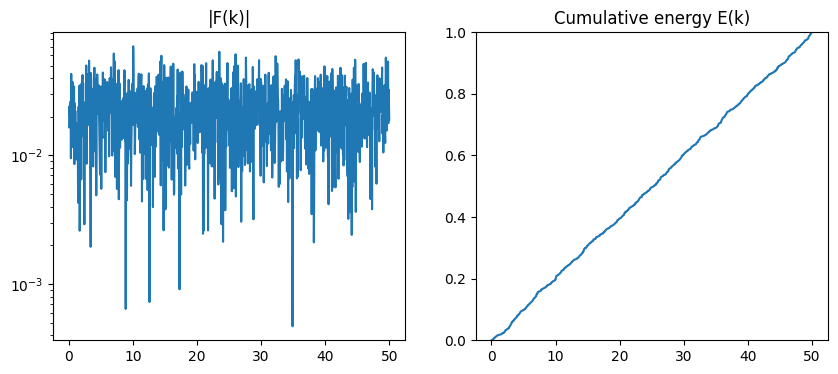

HF-energy = 60.38%
spectral decay exponent α ≈ -0.00


In [63]:
spec = pc_line_spectrum(N, y)
pc1 = spec['pc1']
kvals = pc1['k']          # 波数坐标
F     = pc1['F'][0]       # 若 y 是标量，取第 0 行
E     = pc1['E'][0]

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.semilogy(kvals, np.abs(F)); plt.title('|F(k)|')
plt.subplot(1,2,2); plt.plot(kvals, E); plt.title('Cumulative energy E(k)'); plt.ylim(0,1)
plt.show()

k = spec['pc1']['k'];  F = spec['pc1']['F'][0];  E = spec['pc1']['E'][0]
# 1. 高频能量（>40% Nyquist）
hf_energy = 1 - E[int(0.4*len(k))]
print(f"HF-energy = {hf_energy:.2%}")

# 2. 幂律斜率 α （排除最前 10% 低频避免转折）
from scipy.stats import linregress
frac = 0.1
idx0 = int(frac*len(k))
logk, logA = np.log(k[idx0:]), np.log(np.abs(F[idx0:]))
alpha = -linregress(logk, logA).slope
print(f"spectral decay exponent α ≈ {alpha:.2f}")

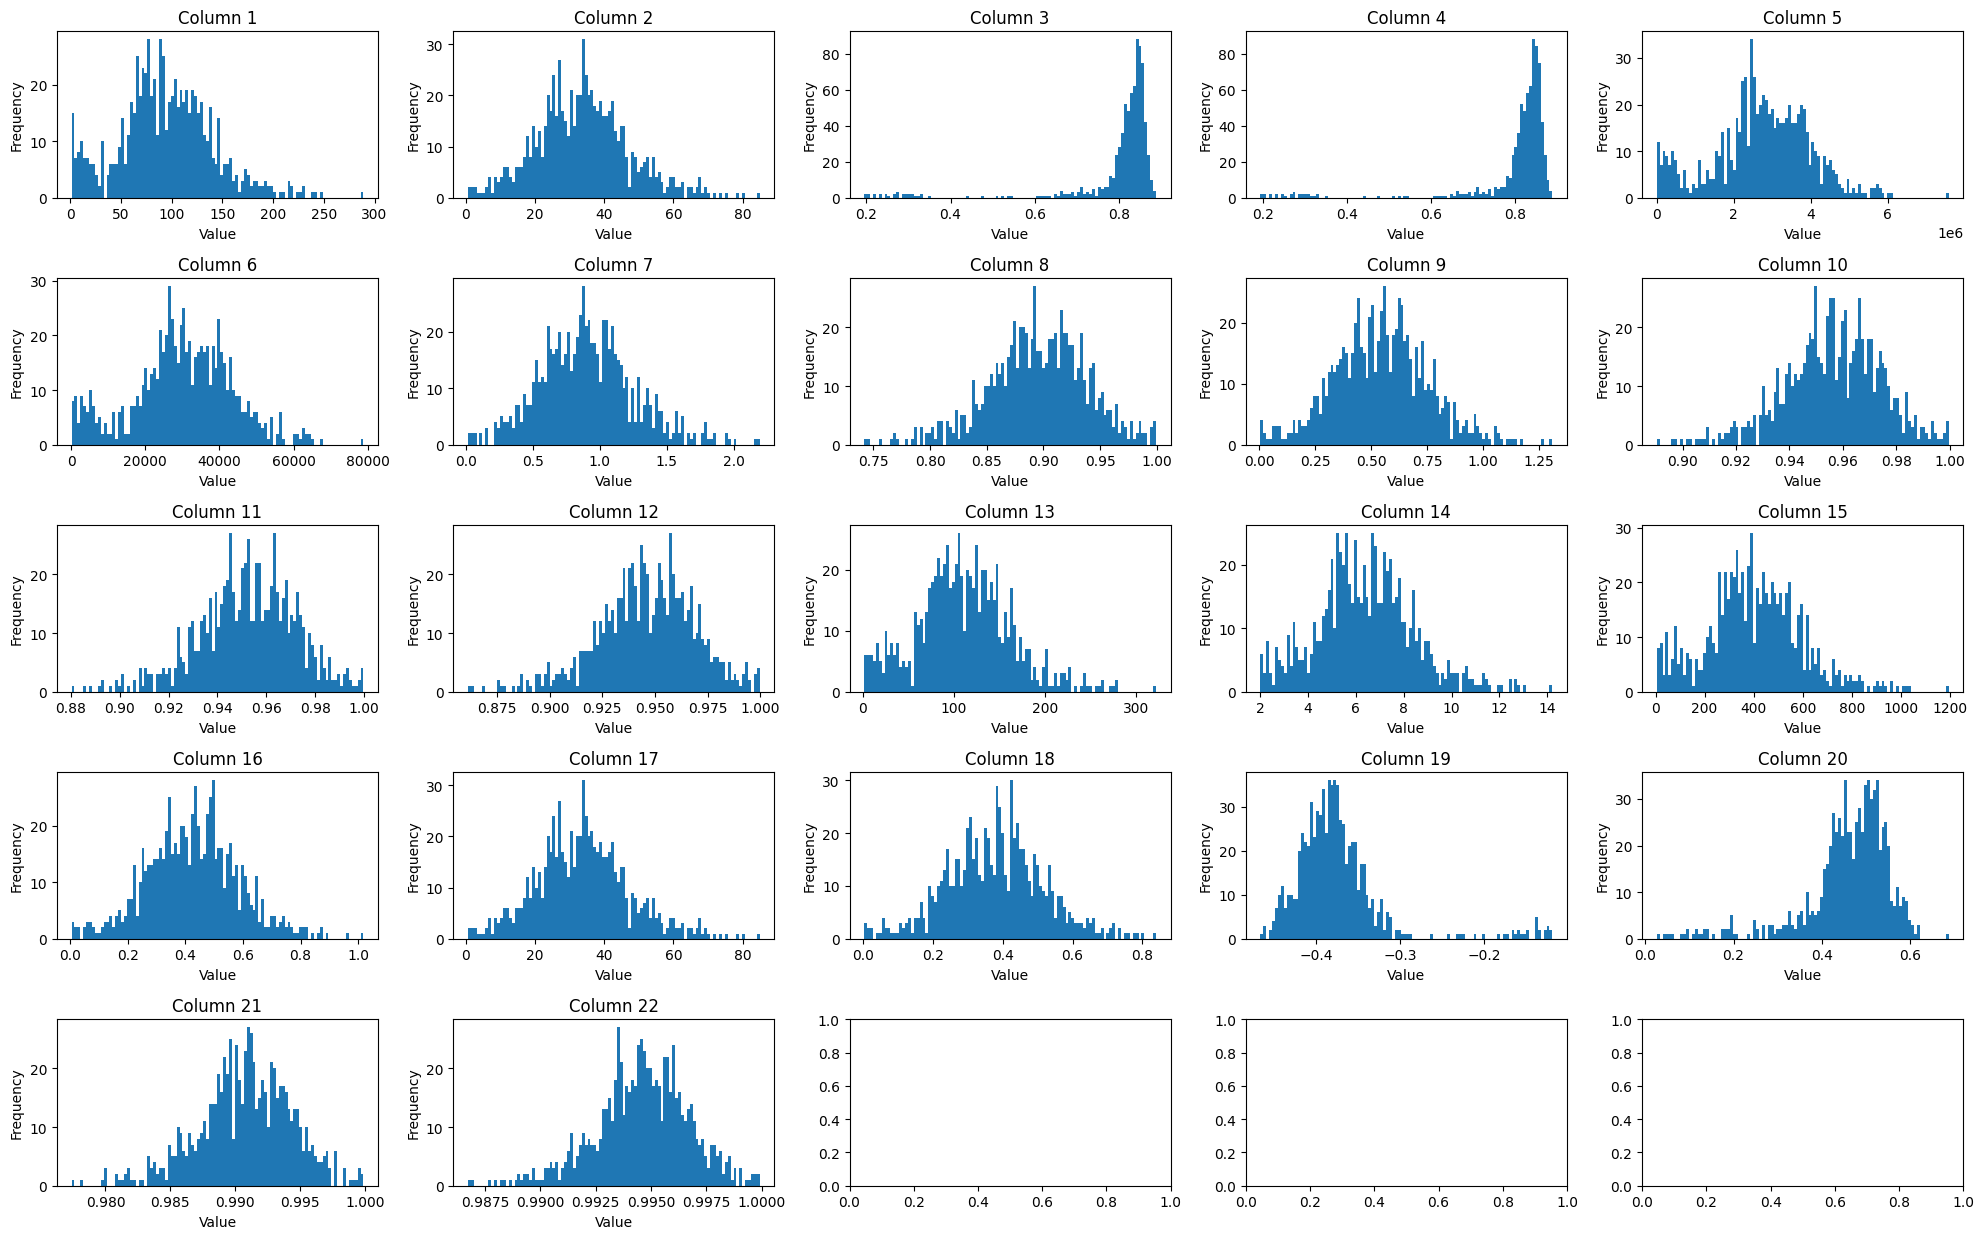

In [46]:
import math
col_num = min(N.shape[1], 30)
cols = min(max(col_num, 2), 5)
rows = math.ceil(col_num / cols)
start_idx = 0

# Create a 6x5 grid of subplots
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*2.5))

# Plot histograms for each column in N
for i in range(col_num):
    row, col = divmod(i, 5)
    axes[row, col].hist(N[:, i+start_idx], bins=100)
    axes[row, col].set_title(f'Column {i+start_idx+1}')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()
plt.show()

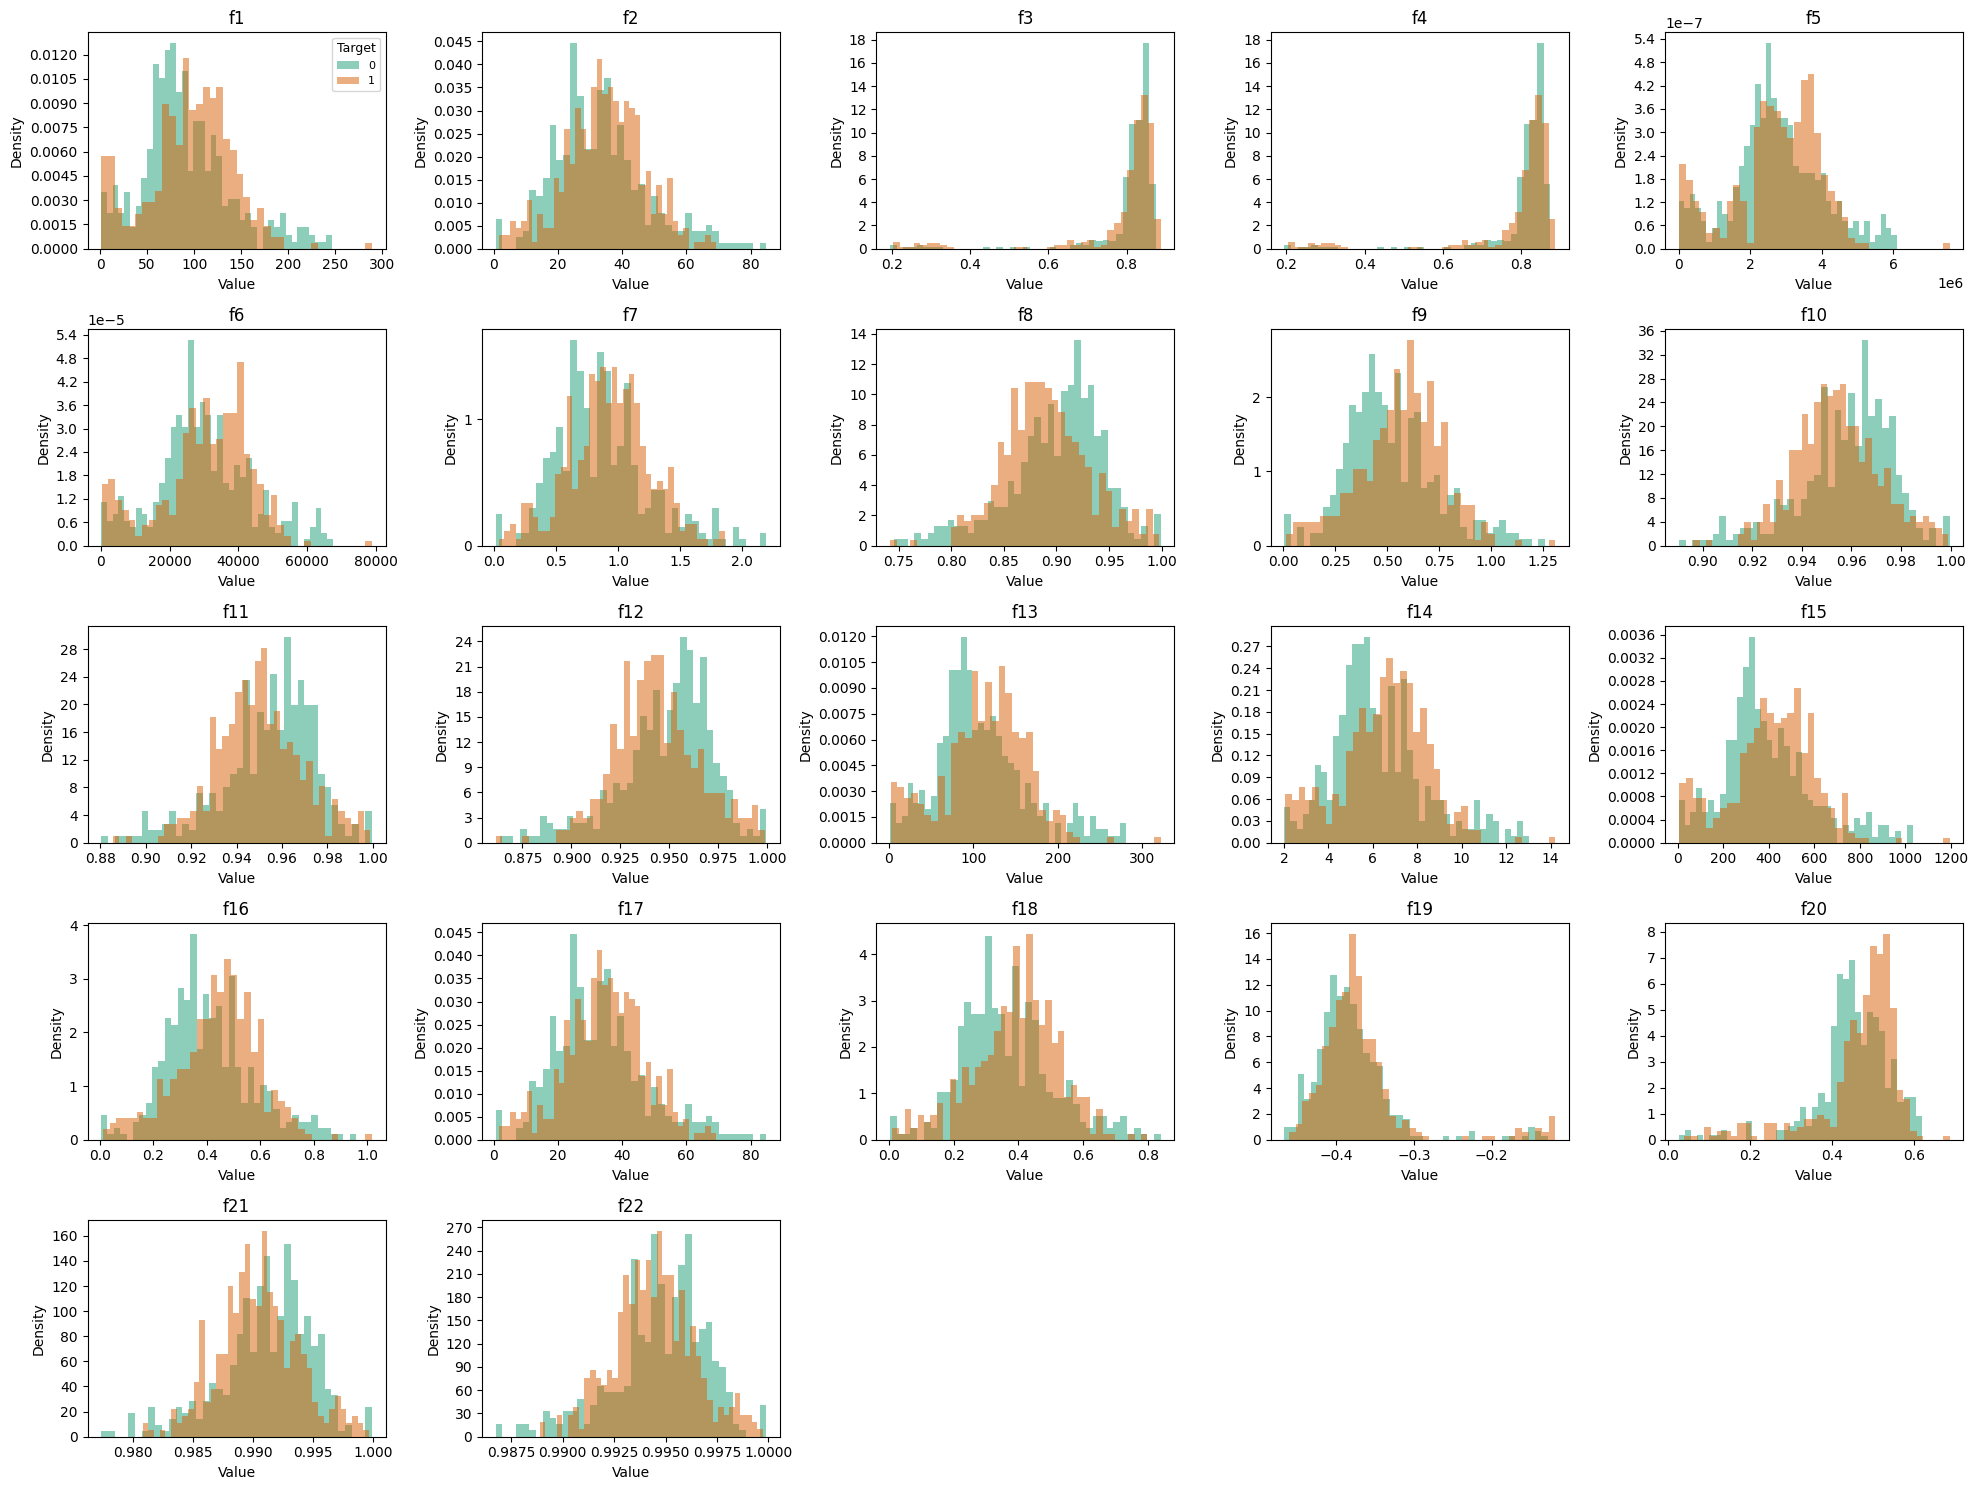

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math, seaborn as sns
from matplotlib.ticker import MaxNLocator

# 假设已有: N (n_samples, n_features), y (n_samples,), is_classification
feature_names = [f"f{i+1}" for i in range(N.shape[1])]
df = pd.DataFrame(N, columns=feature_names)
df["target"] = y

# ---------- 1) 分类 vs. 回归 ----------
y_unique = np.unique(y[~np.isnan(y)])

if is_classification:
    labels = y_unique                                  # ← fix: 统一用 labels
    n_labels = len(labels)

    # ===== 选择更高对比度的调色板 =====
    palette_name = "Dark2" if n_labels <= 8 else "tab10"  # ← 可自行替换
    if n_labels <= 12:
        palette = sns.color_palette(palette_name, n_labels)
    else:
        palette = sns.color_palette("husl", n_labels)

    lab2clr = {lab: palette[i] for i, lab in enumerate(labels)}

    y_bin = None                                       # ← fix: 给 subset_mask 用
else:
    n_bins = 10
    df["target_bin"] = pd.qcut(df["target"], q=n_bins,
                               labels=False, duplicates="drop")
    labels = df["target_bin"].dropna().unique().astype(int)
    labels.sort()

    cmap = plt.cm.get_cmap("turbo", len(labels))
    palette = [cmap(i) for i in range(len(labels))]
    lab2clr = {lab: palette[i] for i, lab in enumerate(labels)}

    # 方便后面判断
    y_bin = pd.qcut(y, q=n_bins, labels=False, duplicates="drop")

# ---------- 2) 画图 ----------
col_num = min(len(feature_names), 30)
cols    = min(col_num, 5)
rows    = math.ceil(col_num / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))

def get_ax(r, c):
    return axes[r*cols + c] if rows == 1 else axes[r, c]

for i, feat in enumerate(feature_names[:col_num]):
    r, c = divmod(i, cols)
    ax = get_ax(r, c)

    for lab in labels:                                # ← fix: 用 labels
        if is_classification:
            subset = df[df["target"] == lab][feat].dropna()
            label_display = str(lab)
        else:
            subset = df[df["target_bin"] == lab][feat].dropna()
            q_low, q_high = df[df["target_bin"] == lab]["target"].agg(["min", "max"])
            label_display = f"[{q_low:.2f}, {q_high:.2f}]"

        if subset.empty:
            continue

        ax.hist(subset, bins=40, alpha=0.5, density=True,
                color=lab2clr[lab], label=label_display)

    ax.set_title(feat)
    ax.set_xlabel("Value"); ax.set_ylabel("Density")
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    if i == 0:
        ax.legend(title="Target", fontsize=8, title_fontsize=9, loc="best")

# 隐藏多余子图
for j in range(col_num, rows*cols):
    r, c = divmod(j, cols)
    get_ax(r, c).axis("off")

plt.tight_layout(); plt.show()

# CDF Transform 

In [50]:

# ---------------------- 0) 依赖 -----------------------------
import numpy as np, matplotlib.pyplot as plt, math
from sklearn.decomposition import PCA
from sklearn.manifold   import TSNE, Isomap
try:              import umap  # optional
except ImportError: umap = None
from mpl_toolkits.mplot3d import Axes3D            # noqa: F401
from scipy.stats import gaussian_kde, norm
from transform.transform_pipeline import DataTransformPipeline
from types import SimpleNamespace
import seaborn as sns

# ------------------------------------------------------------
# 0) Utils function
# ------------------------------------------------------------
def reduce_dim(X, method="pca", n_components=2, perplexity=30):
    if n_components not in (1, 2, 3):
        raise ValueError("n_components 必须是 1 / 2 / 3")
    method = method.lower()
    if method == "pca":
        model = PCA(n_components=n_components, random_state=0)
    elif method == "isomap":
        model = Isomap(n_components=n_components)
    elif method == "tsne":
        model = TSNE(n_components=n_components, random_state=0,
                     perplexity=perplexity)
    elif method == "umap":
        if umap is None:
            raise ImportError("请 pip install umap-learn")
        model = umap.UMAP(n_components=n_components, random_state=0)
    else:
        raise ValueError(f"未知降维方法: {method}")
    return model.fit_transform(X)

def plot_gmm_on_hist(ax, xs, tfm, col_idx, cmap):
    """若 Transform 提供 GMM / bayesGMM 参数，则叠加每个 component 的 pdf"""
    gmm = None
    # 兼容多种命名方式
    for attr in ("gmm_models_", "gmms_", "mixture_models_"):
        if hasattr(tfm, attr) and tfm.__getattribute__(attr) is not None:
            gmm = tfm.__getattribute__(attr)[col_idx]
            break
    if gmm is None:
        return  # 没有 GMM
    K = gmm.weights_.shape[0]
    total_pdf = np.zeros_like(xs)
    for j in range(K):
        mu = float(gmm.means_[j])
        # 兼容 full / diag / spherical
        if gmm.covariances_.ndim == 1:
            var = float(gmm.covariances_[j])
        elif gmm.covariances_.ndim == 2:
            var = float(gmm.covariances_[j, 0])
        else:                             # full matrix
            var = float(gmm.covariances_[j][0, 0])
        w  = float(gmm.weights_[j])
        pdf = w * norm.pdf(xs, mu, np.sqrt(var))
        total_pdf += pdf
        ax.plot(xs, pdf, lw=1.2, color=cmap(j), label=f"Comp {j+1}")
    ax.plot(xs, total_pdf, lw=2.0, color="black", label="Σ components")

/usr2/zihaoye/miniconda3/envs/tabft/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [64]:
# ------------------------------------------------------------
# 1) Prepare transform
# ------------------------------------------------------------
transform_list = [
    {
        'cat_indice': {}
    },
    {
        'num_cdf':
            {
                'cdf_type': 'uniform',
                'n_components': 32,
                'binning_method': 'quantile'
            }
    },
    {
        'norm':
            {
                'policy': 'standard'
            }
    },
]
args = SimpleNamespace(seed=0, dataset=dataset_name)
pipeline = DataTransformPipeline(transform_list, args)

# ------------------------------------------------------------
# 2)  Fit + Transform
# ------------------------------------------------------------
N_data = {"train": N.copy()}
N_trans, *_ = pipeline.fit_transform(N_data=N_data.copy(), C_data=None)
tfm = pipeline.pipeline[0]

In [65]:
tfm = pipeline.pipeline[1]

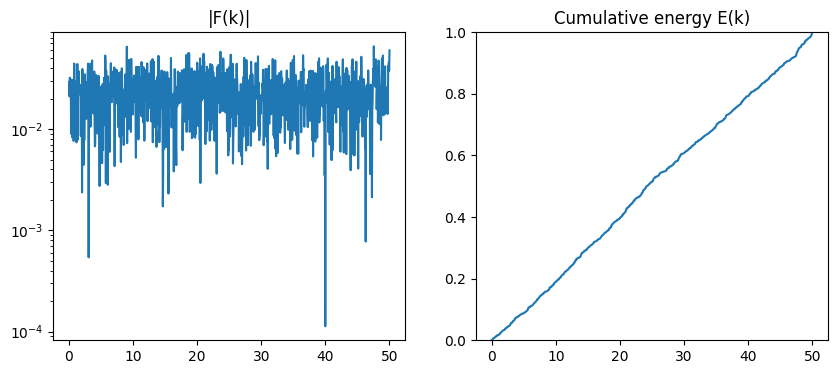

HF-energy = 60.20%
spectral decay exponent α ≈ 0.01


In [66]:
spec = pc_line_spectrum(N_trans['train'], y)
pc1 = spec['pc1']
kvals = pc1['k']          # 波数坐标
F     = pc1['F'][0]       # 若 y 是标量，取第 0 行
E     = pc1['E'][0]

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.semilogy(kvals, np.abs(F)); plt.title('|F(k)|')
plt.subplot(1,2,2); plt.plot(kvals, E); plt.title('Cumulative energy E(k)'); plt.ylim(0,1)
plt.show()

k = spec['pc1']['k'];  F = spec['pc1']['F'][0];  E = spec['pc1']['E'][0]
# 1. 高频能量（>40% Nyquist）
hf_energy = 1 - E[int(0.4*len(k))]
print(f"HF-energy = {hf_energy:.2%}")

# 2. 幂律斜率 α （排除最前 10% 低频避免转折）
from scipy.stats import linregress
frac = 0.1
idx0 = int(frac*len(k))
logk, logA = np.log(k[idx0:]), np.log(np.abs(F[idx0:]))
alpha = -linregress(logk, logA).slope
print(f"spectral decay exponent α ≈ {alpha:.2f}")

In [78]:
# ------------------------------------------------------------
# 1) Prepare transform
# ------------------------------------------------------------
transform_list = [
    {
        'cat_indice': {}
    },
    {
        'norm': 
            {
                'policy': 'standard'
            }
    },
    {
        'nf':
            {
                'expansion': True,
                'flow_layers': 6,
                'd_model': 32,
                'epochs': 100,
                'loss_cfg':
                    {
                        'nll': 0.000001,
                        'sample_cka': 100000.0,
                        'uniform': 10.0
                    }
            }
    },
    {
        'norm':
            {
                'policy': 'standard'
            }
    },
]
args = SimpleNamespace(seed=0, dataset=dataset_name)
pipeline = DataTransformPipeline(transform_list, args)

# ------------------------------------------------------------
# 2)  Fit + Transform
# ------------------------------------------------------------
N_data = {"train": N.copy()}
N_trans, *_ = pipeline.fit_transform(N_data=N_data.copy(), C_data=None)
tfm = pipeline.pipeline[2]

Epoch 10/100, Average Loss: 61.524757
Epoch 20/100, Average Loss: 61.706238
Epoch 30/100, Average Loss: 61.581177
Epoch 40/100, Average Loss: 61.566406
Epoch 50/100, Average Loss: 61.133125
Epoch 60/100, Average Loss: 61.030365
Epoch 70/100, Average Loss: 60.850365
Epoch 80/100, Average Loss: 60.660049
Epoch 90/100, Average Loss: 60.804108
Epoch 100/100, Average Loss: 60.672592


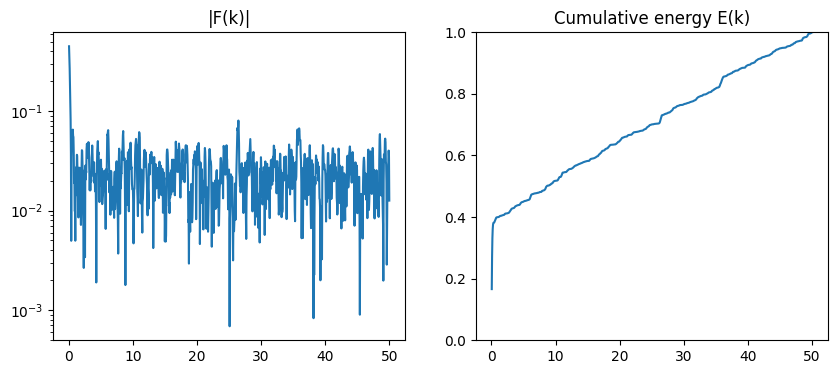

HF-energy = 35.24%
spectral decay exponent α ≈ 0.04


In [79]:
spec = pc_line_spectrum(N_trans['train'], y)
pc1 = spec['pc1']
kvals = pc1['k']          # 波数坐标
F     = pc1['F'][0]       # 若 y 是标量，取第 0 行
E     = pc1['E'][0]

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.semilogy(kvals, np.abs(F)); plt.title('|F(k)|')
plt.subplot(1,2,2); plt.plot(kvals, E); plt.title('Cumulative energy E(k)'); plt.ylim(0,1)
plt.show()

k = spec['pc1']['k'];  F = spec['pc1']['F'][0];  E = spec['pc1']['E'][0]
# 1. 高频能量（>40% Nyquist）
hf_energy = 1 - E[int(0.4*len(k))]
print(f"HF-energy = {hf_energy:.2%}")

# 2. 幂律斜率 α （排除最前 10% 低频避免转折）
from scipy.stats import linregress
frac = 0.1
idx0 = int(frac*len(k))
logk, logA = np.log(k[idx0:]), np.log(np.abs(F[idx0:]))
alpha = -linregress(logk, logA).slope
print(f"spectral decay exponent α ≈ {alpha:.2f}")

In [80]:
# ------------------------------------------------------------
# 3) Parameter
# ------------------------------------------------------------
col_idx   = 0
scatter_alpha  = .6         # 散点透明度
max_hist_cols  = 40         # 最多画多少条直方图

# ------------------------------------------------------------
# 4) Get data
# ------------------------------------------------------------

data_col  = N[:, col_idx]                                # 原始标量
mapping   = tfm.feature_map_[col_idx]                    # {'orig_idx','new_start','size'}
start, k  = mapping["new_start"], mapping["size"]
enc_cols  = N_trans["train"][:, start:start+k]           # (n_samples, k)


# ------------------------------------------------------------
# 5) Global setting
# ------------------------------------------------------------
x_grid = np.linspace(data_col.min(), data_col.max(), 1000)
cmap   = plt.cm.get_cmap("tab10", k)
comp_weight_thr = 1e-3        # 组件权重阈值，小于此值的不画
uniform_color   = "tab:orange"  # Uniform 组件填充色


/tmp/ipykernel_2522570/2085530494.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab10", k)


/usr2/zihaoye/miniconda3/envs/tabft/lib/python3.10/site-packages/sklearn/manifold/_isomap.py:383: UserWarning: The number of connected components of the neighbors graph is 8 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/usr2/zihaoye/miniconda3/envs/tabft/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr2/zihaoye/miniconda3/envs/tabft/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr2/zihaoye/miniconda3/envs/tabft/lib/python3.10/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix

NameError: name 'labels' is not defined

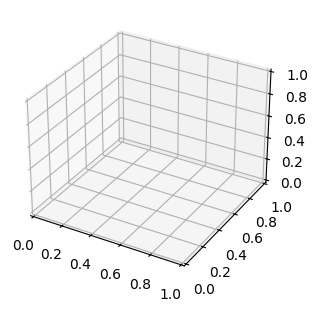

In [74]:
dim_red_method = "isomap"      # pca / isomap / tsne / umap
n_components   = 3          # 1 / 2 / 3
tsne_perplex   = 30         # tsne 专用参数

# 帮助函数: 根据 label 选子集
def subset_mask(lab):
    if is_classification:
        return y == lab
    else:
        return y_bin == lab


# ===========================================================
# A. 降维可视化
# ===========================================================
X_emb = reduce_dim(enc_cols, method=dim_red_method,
                   n_components=n_components, perplexity=tsne_perplex)

fig = plt.figure(figsize=(6, 5) if n_components != 3 else (12, 4))

if n_components == 1:
    for lab in labels:
        mask = subset_mask(lab)
        plt.hist(X_emb[mask].ravel(), bins=60, alpha=.6,
                 color=lab2clr[lab], label=str(lab))
    plt.xlabel("Component 1"); plt.ylabel("Frequency")

elif n_components == 2:
    for lab in labels:
        mask = subset_mask(lab)
        plt.scatter(X_emb[mask, 0], X_emb[mask, 1], s=6, alpha=.65,
                    c=[lab2clr[lab]], label=str(lab), edgecolors="none")
    plt.xlabel("Comp 1"); plt.ylabel("Comp 2")

else:  # 3‑D，用多个视角
    views = [(20, 35), (10, 120), (70, -45)]
    for i, (elev, azim) in enumerate(views, 1):
        ax3d = fig.add_subplot(1, len(views), i, projection="3d")
        for lab in labels:
            mask = subset_mask(lab)
            ax3d.scatter(X_emb[mask, 0], X_emb[mask, 1], X_emb[mask, 2],
                         s=6, alpha=.65, c=[lab2clr[lab]], label=str(lab))
        ax3d.view_init(elev=elev, azim=azim)
        ax3d.set_xlabel("C1"); ax3d.set_ylabel("C2"); ax3d.set_zlabel("C3")
        ax3d.set_title(f"elev={elev}, azim={azim}")

# 只在二维/一维情况下加图例
if n_components < 3:
    plt.legend(title="Target", fontsize=7)

plt.tight_layout(); plt.show()

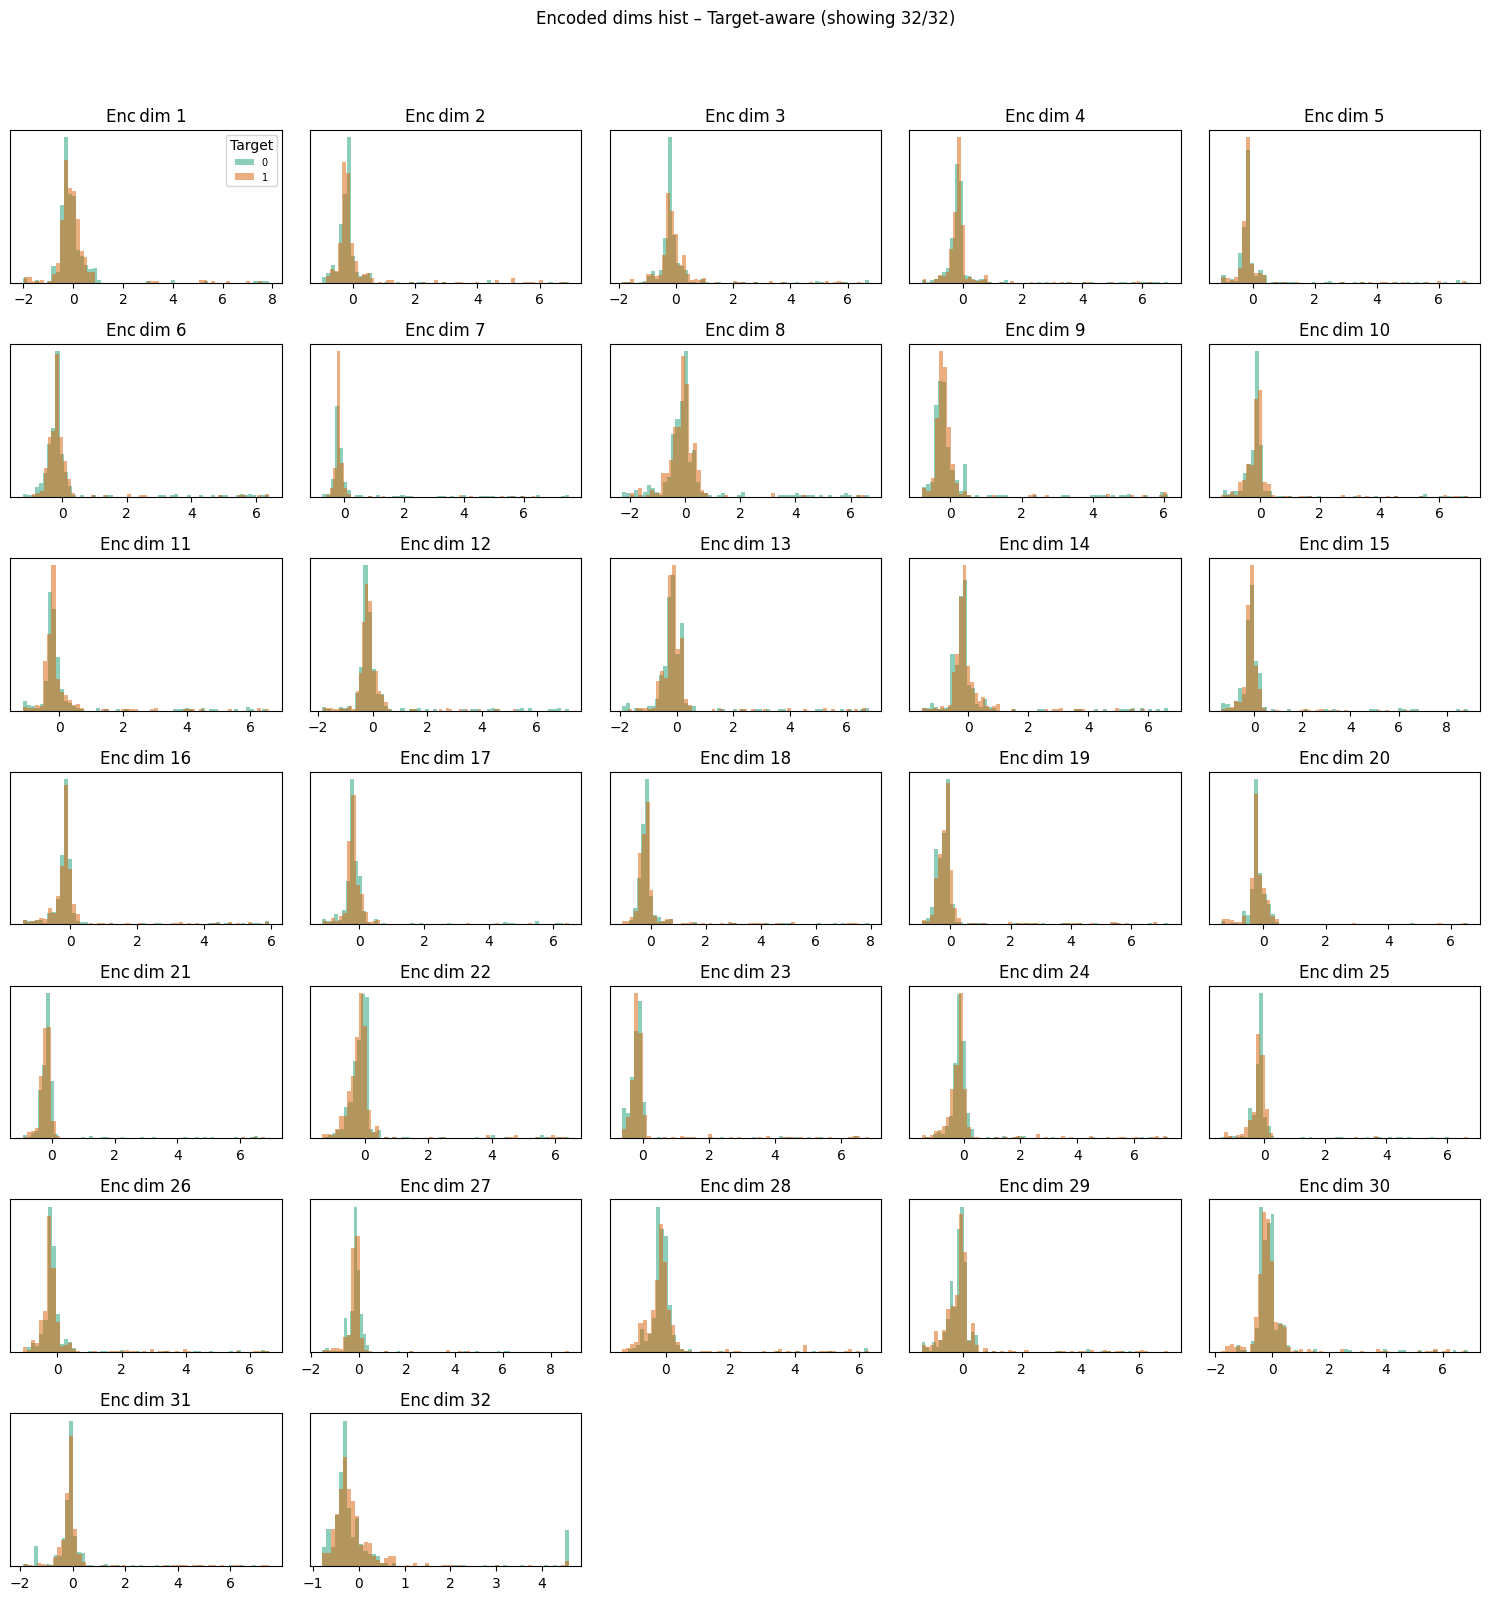

In [81]:
plots = min(k, 100)
cols  = min(plots, 5)
rows  = math.ceil(plots/cols)
figC, axes = plt.subplots(rows, cols, figsize=(cols*3.0, rows*2.4),
                          squeeze=False)

for j in range(plots):
    r, c  = divmod(j, cols)
    ax    = axes[r,c]
    for lab in labels:
        mask = subset_mask(lab)
        ax.hist(enc_cols[mask, j], bins=60, density=True, alpha=.5,
                color=lab2clr[lab], label=str(lab))
    if r == 0 and c == 0:
        ax.legend(fontsize=7, title="Target")
    ax.set_title(f"Enc dim {j+1}")
    ax.set_yticks([])
for ax in axes.flat[plots:]:
    ax.axis("off")
figC.suptitle(f"Encoded dims hist – Target‑aware (showing {plots}/{k})")
figC.tight_layout(rect=[0,0.03,1,0.95])

In [27]:
tfm.cdf_type

'uniform'